# 📝 10-00 · 文本表示与 TF-IDF

> 目标：把「一段文字」变成「一组可计算的数字」。手写**分词（最大匹配）、词袋模型、TF-IDF、余弦相似度**，
> 并与 sklearn 对照，最后跑通一个「查询-检索」小实验。

> 🧩 **生活化类比**：词袋 = 把一段话拆成单词再数出现次数，像给文章做「词频指纹」；
> TF-IDF 更进一步：**词频高 + 稀有**的词才是这篇文章的特色词（"深度学习"比"我们"更能代表这篇文章）。


## 1. 文本预处理管线

1. **分词**（tokenization）：中文按词切分（英文按空格/子词）
2. **规范化**：小写、去标点、统一全半角
3. **去停用词**：的/了/是/and/the——无信息量
4. 可选：词形还原（stemming/lemmatization，英文）

**中文分词的难点**：无空格边界、歧义切分（"研究生命科学"→ 研究/生命/科学 vs 研究生/命/科学）、
未登录词（"祖安人"）。经典算法：最大匹配 / 双向最大匹配 / 隐马尔可夫（HMM）/ 如今预训练分词器。


In [1]:
# ---------- 实验 1：中文分词——正向最大匹配手写 ----------
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DICT = ['自然', '语言', '处理', '自然语言', '学习', '深度', '深度学习', '人工智能',
        '算法', '计算机', '视觉', '分词', '中文', '模型', '训练', '数据',
        '重要', '方向', '需要', '大量', '研究', '应用', '领域']

def max_match(s, max_len=4):
    # 正向最大匹配：每次从最长候选词开始贪心匹配
    i, toks = 0, []
    while i < len(s):
        matched = None
        for L in range(min(max_len, len(s) - i), 0, -1):
            if s[i:i + L] in DICT:
                matched = s[i:i + L]
                i += L
                break
        if matched is None:
            toks.append(s[i]); i += 1
        else:
            toks.append(matched)
    return toks

print('分词结果:', max_match('自然语言处理是人工智能的重要方向'))
print('分词结果:', max_match('深度学习模型需要大量训练数据'))
assert ' '.join(max_match('自然语言处理是人工智能的重要方向')) == '自然语言 处理 是 人工智能 的 重要 方向'
print('要点：最大匹配=贪心最长词；缺点是局部最优（双向匹配可缓解）')


分词结果: ['自然语言', '处理', '是', '人工智能', '的', '重要', '方向']
分词结果: ['深度学习', '模型', '需要', '大量', '训练', '数据']
要点：最大匹配=贪心最长词；缺点是局部最优（双向匹配可缓解）


## 2. 词袋模型（Bag of Words）

- 文档 → 向量：每个词一维，值是出现次数（或 0/1）
- **丢失语序**：'猫追狗' 与 '狗追猫' 向量相同——词袋的经典缺陷
- 词汇表大小即维度：中文语料轻松上万 → **稀疏高维**

| 表示 | 维度 | 信息 |
|------|------|------|
| One-hot | V | 只有词身份 |
| BOW 计数 | V | 词频 |
| TF-IDF | V | 词频×稀有度 |
| 词向量（下一篇） | d<<V | 语义相似度 |


In [2]:
# ---------- 实验 2：手写 BOW + sklearn CountVectorizer 对照 ----------
from sklearn.feature_extraction.text import CountVectorizer

docs = ['深度学习 模型 需要 大量 数据',
        '自然语言 处理 是 人工智能 方向',
        '计算机 视觉 与 自然语言 处理 同属 人工智能']
docs_tok = [d.split() for d in docs]

vocab = sorted({w for d in docs_tok for w in d})
word2id = {w: i for i, w in enumerate(vocab)}
bow = np.zeros((len(docs), len(vocab)), dtype=np.int64)
for k, d in enumerate(docs_tok):
    for w in d:
        bow[k, word2id[w]] += 1
print('手写 BOW:\n', bow)

cv = CountVectorizer(token_pattern=r'(?u)\b\w+\b')   # 允许单字词（默认 \w\w+ 会过滤「与/是」）
bow_sk = cv.fit_transform(docs).toarray()
order = [cv.vocabulary_[w] for w in vocab]
print('sklearn BOW:\n', bow_sk[:, order])
assert np.array_equal(bow, bow_sk[:, order])
print('一致 ✓ | 维度 = 词汇表大小 =', len(vocab))


手写 BOW:
 [[0 0 0 0 1 1 0 0 1 1 0 0 0 1]
 [0 1 0 1 0 0 1 1 0 0 1 0 0 0]
 [1 1 1 1 0 0 0 0 0 0 1 1 1 0]]
sklearn BOW:
 [[0 0 0 0 1 1 0 0 1 1 0 0 0 1]
 [0 1 0 1 0 0 1 1 0 0 1 0 0 0]
 [1 1 1 1 0 0 0 0 0 0 1 1 1 0]]
一致 ✓ | 维度 = 词汇表大小 = 14


## 3. TF-IDF：词频 × 逆文档频率（重点推导）

$$\\text{tf-idf}(t, d) = \\text{tf}(t, d) \\times \\text{idf}(t), \\qquad
\\text{idf}(t) = \\log\\frac{N + 1}{1 + \\text{df}(t)} + 1$$

- **tf**：词在本文档中的频率（计数或归一化）
- **df**：包含该词的文档数；**idf** 随 df 增大而减小
- 直觉：**"深度学习"** 在深度学习论文里 tf 高、在全部语料里 df 中低 → 高分；
  **"我们"** tf 高但每篇都有 → idf≈0 → 低分
- sklearn 默认：`smooth_idf=True`（分子 N+1 分母 1+df）再 `l2` 归一化；我们手写保持一致以便对照


In [3]:
# ---------- 实验 3：手写 TF-IDF + sklearn TfidfVectorizer 对照 ----------
from sklearn.feature_extraction.text import TfidfVectorizer

N = len(docs)
df = {w: sum(1 for d in docs_tok if w in set(d)) for w in vocab}
idf = {w: np.log((N + 1) / (1 + df[w])) + 1 for w in vocab}   # sklearn 平滑 idf
tfidf = np.zeros((N, len(vocab)))
for k, d in enumerate(docs_tok):
    c = Counter(d)
    for w in d:
        tfidf[k, word2id[w]] = c[w] * idf[w]
tfidf = tfidf / np.sqrt((tfidf ** 2).sum(axis=1, keepdims=True) + 1e-12)  # l2 归一化

tv = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')   # 允许单字词，与手写词表对齐
tfidf_sk = tv.fit_transform(docs).toarray()[:, [tv.vocabulary_[w] for w in vocab]]
print('手写 TF-IDF 第一行:\n', np.round(tfidf[0], 3))
print('sklearn 第一行:\n', np.round(tfidf_sk[0], 3))
err = np.abs(tfidf - tfidf_sk).max()
print('最大误差: %.2e' % err)
assert err < 1e-6

# 哪个词最能代表每篇文档？
for k, d in enumerate(docs):
    best = vocab[int(np.argmax(tfidf[k]))]
    print('文档 %d 最具代表性的词: %s' % (k, best))


手写 TF-IDF 第一行:
 [0.    0.    0.    0.    0.447 0.447 0.    0.    0.447 0.447 0.    0.
 0.    0.447]
sklearn 第一行:
 [0.    0.    0.    0.    0.447 0.447 0.    0.    0.447 0.447 0.    0.
 0.    0.447]
最大误差: 2.42e-14
文档 0 最具代表性的词: 大量
文档 1 最具代表性的词: 方向
文档 2 最具代表性的词: 与


## 4. 向量相似度：余弦与检索

$$\\cos(a, b) = \\frac{a \\cdot b}{\\|a\\|\\|b\\|} = \\frac{\\sum_i a_i b_i}{\\sqrt{\\sum_i a_i^2}\\sqrt{\\sum_i b_i^2}}$$

- 余弦只关心**方向**，不关心模长（文档长度差异不影响）
- 检索 = 查询向量与库中所有文档向量算余弦 → 取 Top-K
- TF-IDF 空间里语义相近的文档 → 方向接近


查询「人工智能 方向」的最相似文档:
  Top1  相似度 0.650  「自然语言 处理 是 人工智能 方向」
  Top2  相似度 0.192  「计算机 视觉 与 自然语言 处理 同属 人工智能」
  Top3  相似度 0.000  「深度学习 模型 需要 大量 数据」


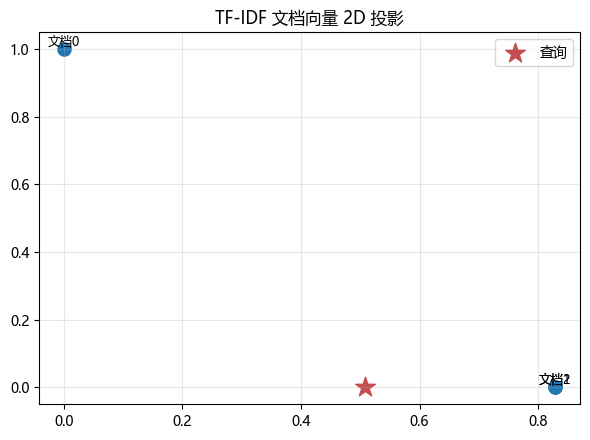

In [4]:
# ---------- 实验 4：查询-检索 + 向量可视化 ----------
from sklearn.decomposition import TruncatedSVD

def cosine(a, B):
    a = a / (np.linalg.norm(a) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return B @ a

query = '人工智能 方向'
qv = tv.transform([query]).toarray()[0]
sims = cosine(qv, tfidf_sk)
order = np.argsort(-sims)
print('查询「%s」的最相似文档:' % query)
for r in order[:3]:
    print('  Top%d  相似度 %.3f  「%s」' % (list(order[:3]).index(r) + 1, sims[r], docs[r]))
assert order[0] == 1   # 含「人工智能」且最长的文档 1 应排第一

# 2D 可视化（TruncatedSVD 降维）
svd = TruncatedSVD(n_components=2, random_state=0)
pts = svd.fit_transform(tfidf_sk)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pts[:, 0], pts[:, 1], s=90)
for k in range(len(docs)):
    ax.annotate('文档%d' % k, (pts[k, 0], pts[k, 1]), fontsize=9, ha='center', va='bottom')
ax.scatter(*svd.transform(qv.reshape(1, -1))[0], marker='*', s=220, color='#C44E52', label='查询')
ax.set_title('TF-IDF 文档向量 2D 投影'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/nlp00_retrieval.png', dpi=110, bbox_inches='tight'); plt.show()


## 5. 局限与演进

1. **词袋的三大缺陷**：丢语序、稀疏高维、不表达语义相似（"汽车"与"车辆"余弦≈0）
2. 演进主线：**BOW → TF-IDF → 词向量（Word2Vec，02 篇）→ 上下文词向量（ELMo/BERT，05 篇）**
3. TF-IDF 仍是传统检索（BM25 变体）的基石，面试常问「为什么 TF-IDF 优于纯词频」
4. 数字敏感：词汇表 V、文档数 N、稀疏度；TF-IDF 向量一般要 L2 归一化

**面试易错**
- idf 公式版本（平滑/非平滑）要能默写一种
- 余弦相似度 vs 欧氏距离：文本稀疏向量用余弦更合理（长度归一化）
- BOW 对语序不敏感是**缺陷**，不要说是特性


## 6. 面试速答（30 秒背诵版）

- **分词难点**：歧义 + 未登录词；最大匹配 / HMM / 预训练分词器
- **BOW**：词频向量，丢语序、稀疏、无语义
- **TF-IDF**：$\\text{tf} \\times \\log\\frac{N+1}{1+\\text{df}} + 1$，词频高且稀有 → 高权重
- **余弦相似度**：方向余弦，长度无关；文本检索标配
- **为什么稀疏**：中文词汇表上万，一篇文档只用到几百词
- **演进**：词袋 → TF-IDF → Word2Vec → 上下文表示


## 7. 自测清单

- [ ] 手写正向最大匹配分词，说出与双向最大匹配的差异
- [ ] 手写 BOW 与 sklearn 对照一致
- [ ] 默写 TF-IDF 公式（含平滑 idf），与 sklearn 对照一致
- [ ] 手写余弦相似度与 Top-K 检索
- [ ] 说出 BOW 三大缺陷与 NLP 表示演进主线
- [ ] 口算：N=1000，某词 df=9 → idf = log(1001/10)+1 ≈ 4.6
- [ ] 说清 tf 高、df 也高的词（"我们"）为什么 TF-IDF 低

> 💡 下一篇 `01-n-gram 与统计语言模型` 从「词向量」走向「句子的概率」。
